<a href="https://colab.research.google.com/github/atul2017/Machine-Learning-Business-Cases/blob/main/IPL_DataAnalysis_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*datetime\.datetime\.utcnow\(\) is deprecated.*",
    category=DeprecationWarning,
    module=r"jupyter_client\..*"
)


## 📝 Question 1: Data Preprocessing & Feature Engineering



Data Cleaning & data imputation

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [ ]:
df = pd.read_csv("IPL_2008-2024.csv")

In [ ]:
df.shape

(1095, 20)

These columns have nan - City, method, player_of_match,winner, result_mragin,target_runs,target_overs,method,

---



In [ ]:
venue_to_city = {
    'Dubai International Cricket Stadium': 'Dubai',
    'Sharjah Cricket Stadium': 'Sharjah'
}

df['city'] = df['venue'].map(venue_to_city).fillna(df['city'])


In [ ]:
df['method'] = df['method'].fillna('Play')

In [ ]:
df.dropna(subset=["winner"],inplace=True)

In [ ]:
venue_to_city = {
    'Dubai International Cricket Stadium': 'Dubai',
    'Sharjah Cricket Stadium': 'Sharjah'
}

df['city'] = df['venue'].map(venue_to_city).fillna(df['city'])

Feature Engineering

In [ ]:
team_to_city = {
    'Royal Challengers Bangalore': 'Bangalore',
    'Kings XI Punjab': 'Chandigarh',
    'Delhi Daredevils':'Delhi',
    'Mumbai Indians':'Mumbai',
    'Kolkata Knight Riders':'Kolkata',
    'Rajasthan Royals':'Jaipur',
    'Deccan Chargers':'Hyderabad',
    'Chennai Super Kings':'Chennai',
       'Kochi Tuskers Kerala':'Kochi', 'Pune Warriors':'Pune', 'Sunrisers Hyderabad':'Hyderabad',
       'Gujarat Lions':'Rajkot', 'Rising Pune Supergiants':'Pune',
       'Rising Pune Supergiant':'Pune', 'Delhi Capitals':'Delhi', 'Punjab Kings':'Chandigarh',
       'Lucknow Super Giants':'Lucknow', 'Gujarat Titans':'Ahmedabad',
       'Royal Challengers Bengaluru':'Bangalore'
}


In [ ]:
df['team1_home_advantage'] = (
    df['team1'].map(team_to_city) == df['city']
)

In [ ]:
df['team2_home_advantage'] = (
    df['team2'].map(team_to_city) == df['city']
)

In [ ]:
df['toss_advantage'] = (
    df['toss_winner'] == df['winner']
)

In [ ]:
team_merge = {
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings',
    'Delhi Daredevils':'Delhi Capitals',
    'Rising Pune Supergiant':'Rising Pune Supergiants',
       'Gujarat Lions':'Gujarat Titans',
       'Kings XI Punjab':'Punjab Kings',
    'Royal Challengers Bangalore':'Royal Challengers Bengaluru',
    'Chennai Super Kings':'Chennai Super Kings',
    'Delhi Capitals':'Delhi Capitals',
     'Gujarat Titans':'Gujarat Titans',
    'Kochi Tuskers Kerala':'Kochi Tuskers Kerala',
    'Kolkata Knight Riders':'Kolkata Knight Riders',
    'Lucknow Super Giants':'Lucknow Super Giants',
    'Mumbai Indians':'Mumbai Indians',
    'Pune Warriors':'Pune Warriors',
    'Punjab Kings':'Punjab Kings',
    'Rajasthan Royals':'Rajasthan Royals',
    'Rising Pune Supergiants':'Rising Pune Supergiants',
    'Royal Challengers Bengaluru':'Royal Challengers Bengaluru',
    'Sunrisers Hyderabad':'Sunrisers Hyderabad'

}

In [ ]:
df['team1'] = df['team1'].map(team_merge)

In [ ]:
df['team2'] = df['team2'].map(team_merge)

In [ ]:
df['toss_winner'] = df['toss_winner'].map(team_merge)

In [ ]:
df['winner'] = df['winner'].map(team_merge)

In [ ]:
venue_merge = {
    'Eden Gardens, Kolkata': 'Eden Gardens',
    'Wankhede Stadium, Mumbai': 'Wankhede Stadium',
    'M Chinnaswamy Stadium, Bengaluru':'M Chinnaswamy Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad':'Rajiv Gandhi International Stadium',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad':'Rajiv Gandhi International Stadium',
    'MA Chidambaram Stadium, Chepauk':'MA Chidambaram Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai':'MA Chidambaram Stadium',
    'Maharashtra Cricket Association Stadium, Pune':'Maharashtra Cricket Association Stadium',
    'Dr DY Patil Sports Academy, Mumbai':'Dr DY Patil Sports Academy',
    'Brabourne Stadium, Mumbai':'Brabourne Stadium',
    'Arun Jaitley Stadium, Delhi':'Arun Jaitley Stadium',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam':'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium',
    'Punjab Cricket Association IS Bindra Stadium, Mohali':'Punjab Cricket Association IS Bindra Stadium',
    'Brabourne Stadium, Mumbai':'Brabourne Stadium',
    'Sawai Mansingh Stadium, Jaipur':'Sawai Mansingh Stadium',
    'Himachal Pradesh Cricket Association Stadium, Dharamsala':'Himachal Pradesh Cricket Association Stadium',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpu':'Maharaja Yadavindra Singh International Cricket Stadium',
    'OUTsurance Oval':'OUTsurance Oval',
    'Dr DY Patil Sports Academy':'Dr DY Patil Sports Academy',
    'Vidarbha Cricket Association Stadium, Jamtha':'Vidarbha Cricket Association Stadium',
    'Barsapara Cricket Stadium, Guwahati':'Barsapara Cricket Stadium',
    'Buffalo Park':'Buffalo Park',
    'De Beers Diamond Oval':'De Beers Diamond Oval',
    'Himachal Pradesh Cricket Association Stadium':'Himachal Pradesh Cricket Association Stadium',
    'Green Park':'Green Park',
    'Punjab Cricket Association IS Bindra Stadium':'Punjab Cricket Association IS Bindra Stadium',
     'Maharaja Yadavindra Singh International Cricket Stadium':'Maharaja Yadavindra Singh International Cricket Stadium',
    'Nehru Stadium':'Nehru Stadium',
     'Shaheed Veer Narayan Singh International Stadium':'Shaheed Veer Narayan Singh International Stadium',
    'Newlands':'Newlands',
    'M.Chinnaswamy Stadium':'M Chinnaswamy Stadium'
}

In [ ]:
df['venue'] = df['venue'].map(venue_merge).fillna(df['venue'])


In [ ]:
df['match_type'].unique()

array(['League', 'Semi Final', 'Final', '3rd Place Play-Off',
       'Qualifier 1', 'Elimination Final', 'Qualifier 2', 'Eliminator'],
      dtype=object)

In [ ]:
def match_imp_category(type):
    if type == 'Final':
        return 'Final'
    elif type == 'League':
        return 'League'
    else:
        return 'Play-Off'

df['match_importance'] = df['match_type'].apply(match_imp_category)


## 📝 Question 2: Text Analytics - Player Performance Analysis



In [ ]:
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt

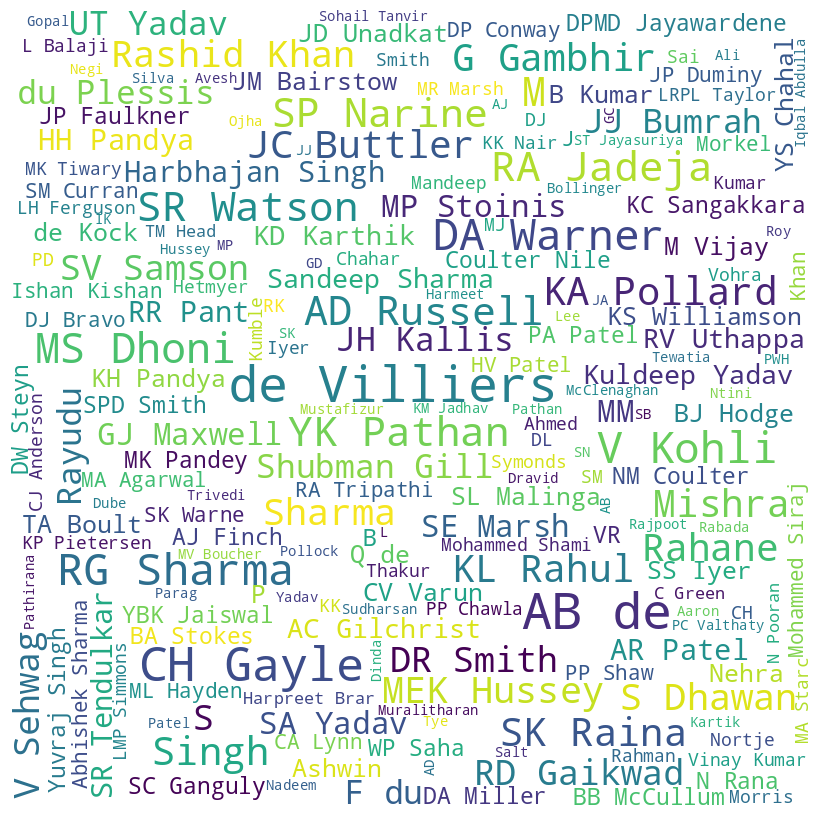

In [ ]:
if __name__ == "__main__":
  # Word cloud for content , X-TO, X-From
  wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = STOPWORDS ,
                max_font_size = 50,
                min_font_size = 10).generate(df['player_of_match'].to_string())
  # plot the WordCloud image
  plt.figure(figsize = (8, 8), facecolor = None)
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout(pad = 0)

  plt.show()

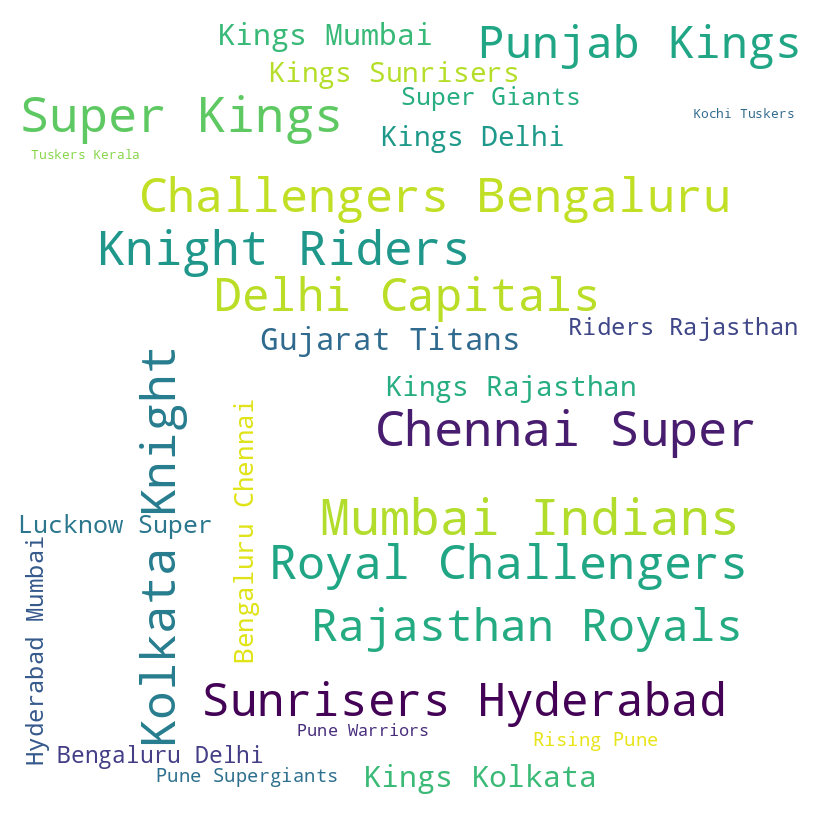

In [ ]:
if __name__ == "__main__":
  # Word cloud for content , X-TO, X-From
  wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = STOPWORDS ,
                max_font_size = 50,
                min_font_size = 10).generate(df['winner'].to_string())
  # plot the WordCloud image
  plt.figure(figsize = (8, 8), facecolor = None)
  plt.imshow(wordcloud)
  plt.axis("off")
  plt.tight_layout(pad = 0)

  plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [ ]:
# Using sklearn CountVectorizer for BoW

#use only for player_of_match column
corpus = df['player_of_match'].dropna().astype(str)
vectorizer = CountVectorizer(token_pattern=r'(?u)\b[A-Za-z .]+\b')
bow_matrix = vectorizer.fit_transform(corpus)
print("BoW Feature Names:", vectorizer.get_feature_names_out())



BoW Feature Names: ['a chandila' 'a kumble' 'a manohar' 'a mishra' 'a nehra' 'a nortje'
 'a singh' 'a symonds' 'a zampa' 'aa jhunjhunwala' 'ab de villiers'
 'ab dinda' 'abhishek sharma' 'ac gilchrist' 'ac voges' 'ad mascarenhas'
 'ad mathews' 'ad russell' 'aj finch' 'aj tye' 'akash madhwal' 'am rahane'
 'anuj rawat' 'ap tare' 'ar patel' 'arshdeep singh' 'as joseph'
 'as rajpoot' 'at rayudu' 'avesh khan' 'azhar mahmood' 'b kumar' 'b lee'
 'b sai sudharsan' 'b stanlake' 'ba bhatt' 'ba stokes' 'bb mccullum'
 'bcj cutting' 'bj hodge' 'bw hilfenhaus' 'c green' 'ca lynn' 'ch gayle'
 'ch morris' 'cj anderson' 'cj jordan' 'cl white' 'cr brathwaite'
 'crd fernando' 'cv varun' 'd padikkal' 'da miller' 'da warner'
 'de bollinger' 'dj bravo' 'dj hooda' 'dj hussey' 'djg sammy' 'dl chahar'
 'dl vettori' 'dp conway' 'dp nannes' 'dpmd jayawardene' 'dr sams'
 'dr smith' 'dw steyn' 'e lewis' 'ejg morgan' 'f du plessis' 'g gambhir'
 'gc smith' 'gd mcgrath' 'gd phillips' 'gh vihari' 'gj bailey'
 'gj maxwe

In [ ]:
bow_df = pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())

In [ ]:
bow_counts = bow_df.sum().sort_values(ascending=False)


In [ ]:
season_docs = df.groupby('season')['player_of_match'].apply(' '.join)

In [ ]:
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b[A-Za-z .]+\b')

X_tfiidf = tfidf.fit_transform(season_docs)

tfidf_df = pd.DataFrame(
    X_tfiidf.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=season_docs.index
)

In [ ]:
player_tfidf_scores = tfidf_df.sum().sort_values(ascending=False)


In [ ]:
df['match_importance'].unique()

array(['League', 'Play-Off', 'Final'], dtype=object)

## 📝 Question 3: Team Performance Clustering



Teams win percentages

In [ ]:
matches_team1 = df['team1'].value_counts()
matches_Team2 = df['team2'].value_counts()


In [ ]:
matches_played = matches_team1.add(matches_Team2)

In [ ]:
wins = df['winner'].value_counts()

In [ ]:
win_pct = (wins/matches_played)*100

In [ ]:
df['team1_win_pct'] = df['team1'].map(win_pct)

In [ ]:
df['team2_win_pct'] = df['team2'].map(win_pct)

In [ ]:
df['result'].unique()

array(['runs', 'wickets', 'tie'], dtype=object)

Toss win to match win ratio

In [ ]:
mask = df['toss_winner'] == df['winner']

In [ ]:
toss_match_win = df[mask]['winner'].value_counts()

In [ ]:
team_toss_wins = df['toss_winner'].value_counts()

In [ ]:
team_toss_win_ratio = (toss_match_win/team_toss_wins)*100

In [ ]:
df['winner_toss_match_win_ratio'] = df['winner'].map(team_toss_win_ratio)

In [ ]:
mask = df['winner'] == df['venue']

Venue familiarity effect: win% at a team’s top‑3 most played venues vs other venues.

In [ ]:
df1 = df[['team1','venue','winner']].copy()
df1.columns = ['team','venue','winner']

df2 = df[['team2','venue','winner']].copy()
df2.columns=['team','venue','winner']

team_matches = pd.concat([df1,df2], ignore_index=True)

In [ ]:
team_matches['win'] = (team_matches['team'] == team_matches['winner']).astype(int)


In [ ]:
top_venues = (team_matches.groupby(['team','venue'])).size().reset_index(name='matches')

In [ ]:
top_venues = (top_venues.sort_values(['team','matches'],ascending=[True,False]).groupby('team').head(3))

In [ ]:
top_set = set(zip(top_venues['team'], top_venues['venue']))

team_matches['is_top_venue'] = team_matches.apply(
    lambda x: (x['team'], x['venue']) in top_set,
    axis=1
)


In [ ]:
venue_effect = (
    team_matches
    .groupby(['team', 'is_top_venue'])['win']
    .mean()
    .reset_index()
)

venue_effect['win_pct'] = venue_effect['win'] * 100


In [ ]:
venue_effect = venue_effect.pivot(
    index='team',
    columns='is_top_venue',
    values='win_pct'
).fillna(0)

venue_effect.columns = ['other_venues_win_pct', 'top3_venues_win_pct']


In [ ]:
venue_effect['familiarity_advantage'] = (
    venue_effect['top3_venues_win_pct']
    - venue_effect['other_venues_win_pct']
)


In [ ]:
top3_map = venue_effect['top3_venues_win_pct'].to_dict()
other_map = venue_effect['other_venues_win_pct'].to_dict()


In [ ]:
df['team1_top3_win_pct'] = df['team1'].map(top3_map)
df['team1_other_win_pct'] = df['team1'].map(other_map)


In [ ]:
df['team2_top3_win_pct'] = df['team2'].map(top3_map)
df['team2_other_win_pct'] = df['team2'].map(other_map)


In [ ]:
df['super_over'].unique()

array(['N', 'Y'], dtype=object)

Let's convert all columns in numbers first before we apply any algorithm.\

In [ ]:
df['team1_home_advantage'] = df['team1_home_advantage'].astype(int)

In [ ]:
df['toss_advantage'] = df['toss_advantage'].astype(int)

In [ ]:
df['team2_home_advantage'] = df['team2_home_advantage'].astype(int)

In [ ]:
df['super_over'] = df['super_over'].astype(bool)

In [ ]:
df['super_over'] = df['super_over'].astype(int)

In [ ]:
df['result_margin'].fillna(0,inplace=True)

/tmp/ipykernel_933/1506646421.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['result_margin'].fillna(0,inplace=True)


In [ ]:
df[df['match_type']=='Qualifier 1']

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,team2_home_advantage,toss_advantage,match_importance,team1_win_pct,team2_win_pct,winner_toss_match_win_ratio,team1_top3_win_pct,team1_other_win_pct,team2_top3_win_pct,team2_other_win_pct
244,501268,2011,Mumbai,2011-05-24,Qualifier 1,SK Raina,Wankhede Stadium,Royal Challengers Bengaluru,Chennai Super Kings,Chennai Super Kings,...,0,1,Play-Off,48.809524,58.227848,61.983471,48.305085,49.253731,65.454545,51.968504
318,548378,2012,Pune,2012-05-22,Qualifier 1,YK Pathan,Subrata Roy Sahara Stadium,Delhi Capitals,Kolkata Knight Riders,Kolkata Knight Riders,...,0,1,Play-Off,46.000000,52.191235,55.737705,43.434343,47.682119,55.833333,48.854962
394,598070,2013,Delhi,2013-05-21,Qualifier 1,MEK Hussey,Feroz Shah Kotla,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,...,0,1,Play-Off,58.227848,55.172414,61.983471,65.454545,51.968504,61.403509,50.340136
454,734043,2014,Kolkata,2014-05-27,Qualifier 1,UT Yadav,Eden Gardens,Punjab Kings,Kolkata Knight Riders,Punjab Kings,...,1,0,Play-Off,45.528455,52.191235,55.737705,52.000000,42.690058,55.833333,48.854962
513,829817,2015,Mumbai,2015-05-19,Qualifier 1,KA Pollard,Wankhede Stadium,Chennai Super Kings,Mumbai Indians,Mumbai Indians,...,1,1,Play-Off,58.227848,55.172414,54.545455,65.454545,51.968504,61.403509,50.340136
573,981013,2016,Bangalore,2016-05-24,Qualifier 1,AB de Villiers,M Chinnaswamy Stadium,Gujarat Titans,Royal Challengers Bengaluru,Royal Challengers Bengaluru,...,1,1,Play-Off,54.666667,48.809524,50.833333,48.484848,59.523810,48.305085,49.253731
632,1082647,2017,Mumbai,2017-05-16,Qualifier 1,Washington Sundar,Wankhede Stadium,Mumbai Indians,Rising Pune Supergiants,Mumbai Indians,...,0,0,Play-Off,55.172414,50.000000,61.538462,61.403509,50.340136,52.941176,46.153846
692,1136617,2018,Mumbai,2018-05-22,Qualifier 1,F du Plessis,Wankhede Stadium,Sunrisers Hyderabad,Chennai Super Kings,Chennai Super Kings,...,0,1,Play-Off,45.525292,58.227848,61.983471,47.252747,44.578313,65.454545,51.968504
752,1181764,2019,Chennai,2019-05-07,Qualifier 1,SA Yadav,MA Chidambaram Stadium,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,...,0,0,Play-Off,58.227848,55.172414,54.545455,65.454545,51.968504,61.403509,50.340136
812,1237177,2020,Dubai,2020-11-05,Qualifier 1,JJ Bumrah,Dubai International Cricket Stadium,Mumbai Indians,Delhi Capitals,Delhi Capitals,...,0,0,Play-Off,55.172414,46.000000,54.545455,61.403509,50.340136,43.434343,47.682119


In [ ]:
df_arm = df.copy()

In [ ]:
df.drop(columns=['id','date','city'],inplace=True)

In [ ]:
df.shape

(1090, 28)

In [ ]:
df['result'].unique()

array(['runs', 'wickets', 'tie'], dtype=object)

Drop columns - date, id, city

Different type of encoding -

one-hot - match_type, toss_decision, method, match_importance,result,winner, team1, team2, toss_winner

frequency encoding - venue,umpire1, umpire2,player_of_match
   

In [ ]:
num_cols = ['season','result_margin','target_runs','target_overs','super_over','team1_home_advantage','team2_home_advantage','toss_advantage',
              'winner_toss_match_win_ratio','team1_top3_win_pct','team1_top3_win_pct','team2_top3_win_pct','team2_other_win_pct']


In [ ]:
X_num = df[num_cols].copy()

In [ ]:
ohe_cols =['team1','team2','match_type','toss_winner','toss_decision','method','match_importance','result','winner']


In [ ]:
X_ohe = pd.get_dummies(df[ohe_cols], drop_first=False)

In [ ]:
X_freq = pd.DataFrame(index=df.index)
X_freq['venue_freq'] = df['venue'].map(df['venue'].value_counts(normalize=True))
X_freq['umpire1_freq'] = df['umpire1'].map(df['umpire1'].value_counts(normalize=True))
X_freq['umpire2_freq'] = df['umpire2'].map(df['umpire2'].value_counts(normalize=True))
X_freq['player_of_match_freq'] = df['player_of_match'].map(df['player_of_match'].value_counts(normalize=True))

In [ ]:
X = pd.concat([X_num, X_ohe, X_freq], axis=1)


In [ ]:
X.shape

(1090, 87)

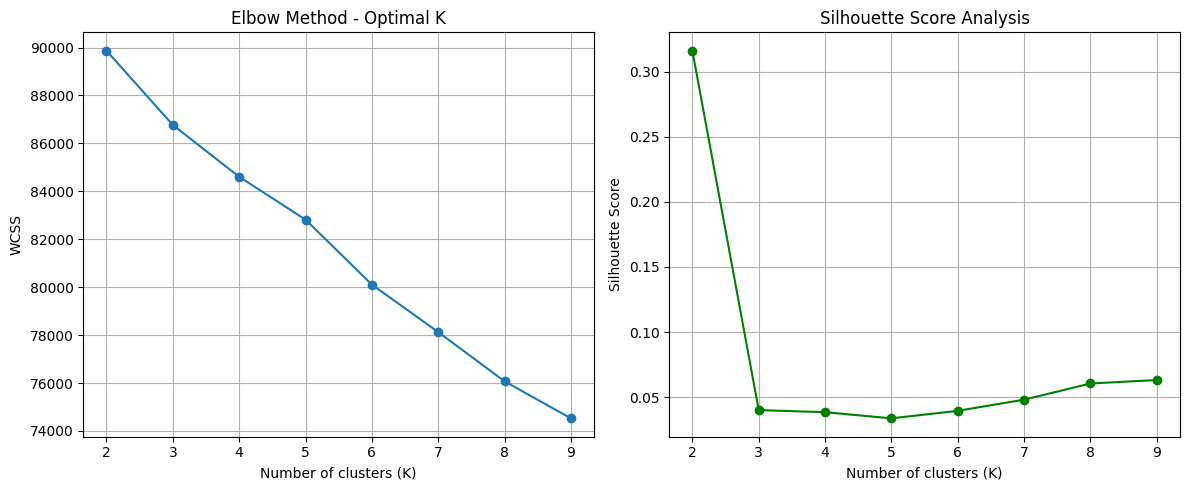

2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method to determine the optimal number of clusters
wcss = []
silhouette_scores = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot WCSS (Elbow Method)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score Analysis')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Return best K based on max silhouette score
optimal_k = K_range[silhouette_scores.index(max(silhouette_scores))]
optimal_k

In [ ]:
# Apply KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)


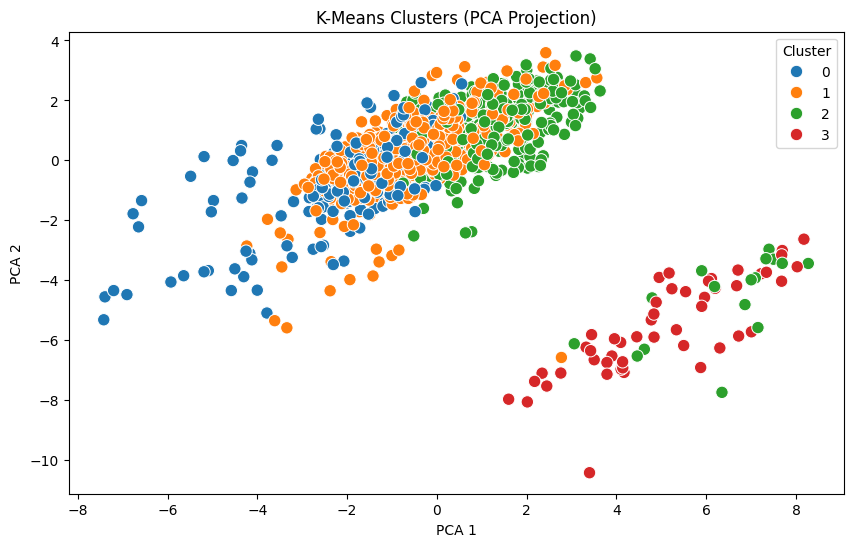

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=df['Cluster'],
    palette='tab10',
    s=80
)

plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [ ]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_profile)


              season  result_margin  target_runs  target_overs  super_over  \
Cluster                                                                      
0        2015.324074      17.351852   164.629630     19.740741         1.0   
1        2016.498990      15.498990   163.949495     19.741818         1.0   
2        2016.057576      18.457576   169.503030     19.848485         1.0   
3        2016.306122      21.632653   163.775510     19.714286         1.0   

         team1_home_advantage  team2_home_advantage  toss_advantage  \
Cluster                                                               
0                    0.569444              0.074074        0.379630   
1                    0.515152              0.084848        0.604040   
2                    0.518182              0.142424        0.442424   
3                    0.122449              0.142857        0.551020   

         team1_win_pct  team2_win_pct  winner_toss_match_win_ratio  \
Cluster                           

In [ ]:
for c in sorted(df['Cluster'].unique()):
    print(f"\nCluster {c}")
    print(df[df['Cluster']==c]['winner_toss_match_win_ratio'].value_counts().head(5))



Cluster 0
winner_toss_match_win_ratio
47.286822    113
43.511450     19
54.545455     16
50.833333     14
41.284404     13
Name: count, dtype: int64

Cluster 1
winner_toss_match_win_ratio
55.737705    100
50.833333     89
43.511450     81
41.284404     79
50.847458     77
Name: count, dtype: int64

Cluster 2
winner_toss_match_win_ratio
61.983471    123
54.545455    120
41.284404     19
50.847458     18
50.833333     14
Name: count, dtype: int64

Cluster 3
winner_toss_match_win_ratio
61.983471    12
54.545455     8
55.737705     7
50.833333     6
43.511450     6
Name: count, dtype: int64


The clustering reveals four distinct match patterns. Cluster 0 represents home-dominant matches where venue familiarity strongly influences outcomes. Cluster 1 consists of balanced matches with minimal home or toss advantage. Cluster 2 highlights venue specialists achieving large-margin victories, often away from home. Cluster 3 captures elite, high-pressure matches where toss decisions and small margins play a crucial role.

## 📝 Question 4: Strategic Pattern Mining



In [ ]:
transactions = []

for _, row in df.iterrows():
    transaction = [
        f"TossWinner={row['toss_winner']}",
        f"Decision={row['toss_decision']}",
        f"Winner={row['winner']}"

    ]
    transactions.append(transaction)

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_arm = pd.DataFrame(te_array, columns=te.columns_)


In [ ]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    df_arm,
    min_support=0.05,
    use_colnames=True

)

In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.6
)

rules = rules.sort_values('lift', ascending=False)


In [ ]:
transactions = []

for _, row in df.iterrows():
    transaction = [
        f"Winner={row['winner']}",
        f"TossWinner={row['toss_winner']}"

    ]
    transactions.append(transaction)

In [ ]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_arm = pd.DataFrame(te_array, columns=te.columns_)
frequent_itemsets = apriori(
    df_arm,
    min_support=0.05,
    use_colnames=True

)
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.6
)
rules = rules.sort_values('lift', ascending=False)

In [ ]:
rules[['antecedents','consequents','support','confidence','lift']]

,antecedents,consequents,support,confidence,lift
0,(TossWinner=Chennai Super Kings),(Winner=Chennai Super Kings),0.068807,0.619835,4.895796


In [ ]:
transactions = []

for _, row in df.iterrows():
    transaction = [
        f"MatchPlayer={row['player_of_match']}",
        f"Venue={row['venue']}",
        f"Winner={row['winner']}"

    ]
    transactions.append(transaction)

In [ ]:
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df_arm = pd.DataFrame(te_array, columns=te.columns_)
frequent_itemsets = apriori(
    df_arm,
    min_support=0.01,
    use_colnames=True

)
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.5
)
rules = rules.sort_values('lift', ascending=False)

## 📝 Question 5: Match Outcome Prediction - Logistic Regression



In [ ]:
num_cols = ['season','result_margin','target_runs','target_overs','super_over','team1_home_advantage','team2_home_advantage','toss_advantage',
              'winner_toss_match_win_ratio','team1_top3_win_pct','team1_top3_win_pct','team2_top3_win_pct','team2_other_win_pct']


In [ ]:
X_num = df[num_cols].copy()

In [ ]:
ohe_cols =['team1','team2','match_type','toss_winner','toss_decision','method','match_importance','result']
X_ohe = pd.get_dummies(df[ohe_cols], drop_first=False)

In [ ]:
X_freq = pd.DataFrame(index=df.index)
X_freq['venue_freq'] = df['venue'].map(df['venue'].value_counts(normalize=True))
X_freq['umpire1_freq'] = df['umpire1'].map(df['umpire1'].value_counts(normalize=True))
X_freq['umpire2_freq'] = df['umpire2'].map(df['umpire2'].value_counts(normalize=True))
X_freq['player_of_match_freq'] = df['player_of_match'].map(df['player_of_match'].value_counts(normalize=True))

In [ ]:
X = pd.concat([X_num, X_ohe, X_freq], axis=1)


In [ ]:
y = (df['winner'] == df['team1']).astype(int)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7064220183486238
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       110
           1       0.72      0.66      0.69       108

    accuracy                           0.71       218
   macro avg       0.71      0.71      0.71       218
weighted avg       0.71      0.71      0.71       218



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "L2 (Ridge)": LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000),
    "L1 (Lasso)": LogisticRegression(penalty='l1', solver='saga', max_iter=5000)
}

results = {}

for name, clf in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),  # with_mean=False for sparse dummies
        ('lr', clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    results[name] = auc

    print(f"\n{name}")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))




L2 (Ridge)
ROC-AUC: 0.7532
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       110
           1       0.72      0.66      0.69       108

    accuracy                           0.71       218
   macro avg       0.71      0.71      0.71       218
weighted avg       0.71      0.71      0.71       218


L1 (Lasso)
ROC-AUC: 0.7529
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       110
           1       0.74      0.66      0.70       108

    accuracy                           0.72       218
   macro avg       0.72      0.72      0.71       218
weighted avg       0.72      0.72      0.71       218



In [ ]:
import numpy as np

def top_features_from_pipeline(pipe, feature_names, top_n=15):
    lr = pipe.named_steps['lr']
    coefs = lr.coef_.ravel()  # binary case

    top_pos_idx = np.argsort(coefs)[-top_n:][::-1]  # strongest positive
    top_neg_idx = np.argsort(coefs)[:top_n]         # strongest negative

    top_pos = pd.DataFrame({
        "feature": feature_names[top_pos_idx],
        "coef": coefs[top_pos_idx]
    })
    top_neg = pd.DataFrame({
        "feature": feature_names[top_neg_idx],
        "coef": coefs[top_neg_idx]
    })

    return top_pos, top_neg

# Refit and extract for each
for name, clf in models.items():
    pipe = Pipeline([
        ('scaler', StandardScaler(with_mean=False)),
        ('lr', clf)
    ])
    pipe.fit(X_train, y_train)

    top_pos, top_neg = top_features_from_pipeline(pipe, X.columns.to_numpy(), top_n=15)

    print(f"\n===== {name}: Top features increasing Team1 win probability =====")
    print(top_pos.to_string(index=False))

    print(f"\n===== {name}: Top features decreasing Team1 win probability =====")
    print(top_neg.to_string(index=False))



===== L2 (Ridge): Top features increasing Team1 win probability =====
                          feature     coef
                      result_runs 0.535814
    match_type_3rd Place Play-Off 0.192156
       toss_winner_Mumbai Indians 0.167873
toss_winner_Kolkata Knight Riders 0.151074
     match_type_Elimination Final 0.138998
               team1_top3_win_pct 0.135095
               team1_top3_win_pct 0.135095
        team2_Sunrisers Hyderabad 0.132238
                      method_Play 0.130579
       team1_Lucknow Super Giants 0.129681
           team2_Rajasthan Royals 0.114244
       team2_Lucknow Super Giants 0.112195
            match_type_Eliminator 0.109985
        team1_Sunrisers Hyderabad 0.108643
           match_type_Qualifier 2 0.102636

===== L2 (Ridge): Top features decreasing Team1 win probability =====
                         feature      coef
                  result_wickets -0.494709
                  toss_advantage -0.250069
 toss_winner_Sunrisers Hyderabad -0.23343

In [ ]:
pipe_l1 = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('lr', LogisticRegression(penalty='l1', solver='saga', max_iter=5000))
])
pipe_l1.fit(X_train, y_train)

coefs = pipe_l1.named_steps['lr'].coef_.ravel()
selected = (coefs != 0).sum()

print("L1 selected features:", selected, "out of", len(coefs))


L1 selected features: 68 out of 74


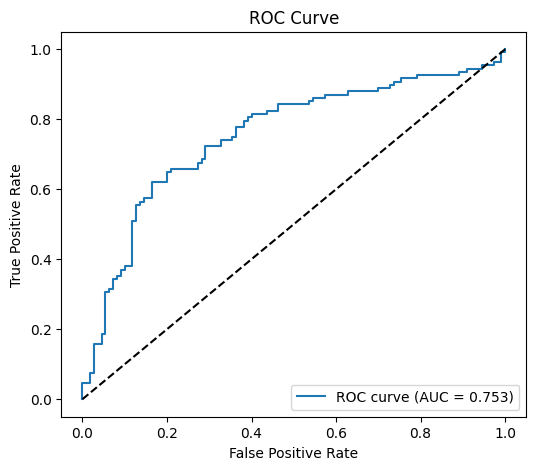

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predicted probabilities for positive class
y_prob = pipe.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')  # random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


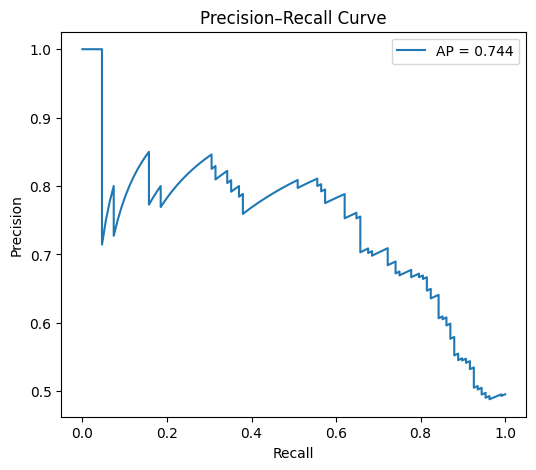

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f'AP = {avg_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Get model from pipeline
lr = pipe.named_steps['lr']

coefs = lr.coef_.ravel()
feature_names = X_train.columns

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
})

coef_df['abs_coef'] = coef_df['coefficient'].abs()


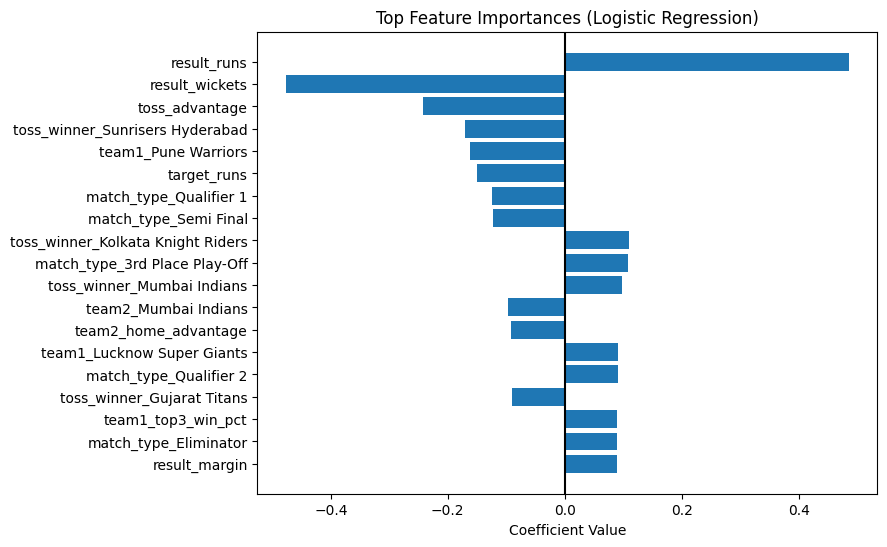

In [ ]:
top_features = coef_df.sort_values('abs_coef', ascending=False).head(20)

plt.figure(figsize=(8,6))
plt.barh(top_features['feature'], top_features['coefficient'])
plt.axvline(0, color='black')
plt.xlabel('Coefficient Value')
plt.title('Top Feature Importances (Logistic Regression)')
plt.gca().invert_yaxis()
plt.show()


## 📝 Question 6: Venue Recommendation System



In [ ]:
def avg_run_score(row):
  if row['result'] == 'runs':
    total_run = row['target_runs'] + (row['target_runs'] - row['result_margin'])
  elif row['result'] == 'wickets':
    total_run = 2 * row['target_runs'] + 1
  else:
    total_run = 2 * row['target_runs']
  return total_run

df['total_run_score'] = df.apply(avg_run_score, axis =1)


In [ ]:
venue_average_score = df.groupby('venue')['total_run_score'].mean().reset_index()

In [ ]:
df.drop(columns='total_run_score',inplace=True)

In [ ]:
df = df.merge(
    venue_average_score[['venue','total_run_score']],
    on = 'venue',
    how = 'left'
)

In [ ]:
df.rename(columns={'total_run_score':'avg_venue_runs_scored'},inplace=True)

In [ ]:
venue_toss_advatage = df.groupby('venue')['winner_toss_match_win_ratio'].mean().reset_index()

In [ ]:
venue_toss_advatage.rename(columns={'winner_toss_match_win_ratio':'venue_winner_toss_match_win_ratio'},inplace=True)

In [ ]:
df = df.merge(
    venue_toss_advatage[['venue','venue_winner_toss_match_win_ratio']],
    on = 'venue',
    how = 'left'
)

In [ ]:
df.rename(columns={'winner_toss_match_win_ratio_y':'venue_winner_toss_match_win_ratio'},inplace=True)

Content Based Reccomondation System

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

venue_features = (
    df.groupby('venue',as_index=True)[
        ['avg_venue_runs_scored','venue_winner_toss_match_win_ratio']
    ].mean()
)

scaler = StandardScaler()
X = scaler.fit_transform(venue_features)

cosine_sim_matrix = cosine_similarity(X)
cosine_sim_matrix = pd.DataFrame(
    cosine_sim_matrix,
    index = venue_features.index,
    columns = venue_features.index
)

In [ ]:
def recommend_similar_venues(venue_name,top_n=5):
  if venue_name not in cosine_sim_matrix:
    raise ValueError("Venue not found in data")
  sims = cosine_sim_matrix.loc[venue_name].drop(venue_name)
  return sims.sort_values(ascending=False).head(top_n)

In [ ]:
 top_5_similar_venues = recommend_similar_venues("Feroz Shah Kotla",top_n=5)


## 📝 Question 7: Performance Trend Analysis



In [ ]:
df1 = df[['season','team1','winner','toss_advantage']].copy()
df1.columns = ['season','team','winner','toss_advantage']

df2 = df[['season','team2','winner','toss_advantage']].copy()
df2.columns = ['season','team','winner','toss_advantage']


In [ ]:
all_matches = pd.concat([df1,df2])

In [ ]:
all_matches['win'] = (all_matches['team'] == all_matches['winner']).astype(int)

In [ ]:
yearly_win_pct =(
    all_matches
    .groupby(['season','team'])
    .agg(
        matches_played = ('team','count'),
        wins = ('win','sum'),
        toss_advantage = ('toss_advantage','sum')
    )
    .reset_index()
)
yearly_win_pct['win_pct'] =(
    yearly_win_pct['wins']/yearly_win_pct['matches_played']
)*100

yearly_win_pct['toss_advnt_pct'] =(
    yearly_win_pct['toss_advantage']/yearly_win_pct['matches_played']
)*100

In [ ]:
yearly_win_pct.sort_values('win_pct',ascending=False)

,season,team,matches_played,wins,toss_advantage,win_pct,toss_advnt_pct
5,2008,Rajasthan Royals,16,13,10,81.250000,62.500000
139,2024,Kolkata Knight Riders,14,11,6,78.571429,42.857143
118,2022,Gujarat Titans,16,12,8,75.000000,50.000000
36,2012,Kolkata Knight Riders,17,12,8,70.588235,47.058824
56,2014,Punjab Kings,17,12,8,70.588235,47.058824
...,...,...,...,...,...,...,...
64,2015,Punjab Kings,14,3,6,21.428571,42.857143
115,2021,Sunrisers Hyderabad,14,3,4,21.428571,28.571429
44,2013,Delhi Capitals,16,3,8,18.750000,50.000000
7,2008,Sunrisers Hyderabad,14,2,7,14.285714,50.000000


Linear regression for predicting next session performance

In [ ]:
yearly = yearly_win_pct.sort_values(['team','season'])

In [ ]:
yearly['prev_matches'] = yearly.groupby('team')['matches_played'].shift(1)
yearly['prev_wins'] = yearly.groupby('team')['wins'].shift(1)
yearly['prev_win_pct'] = yearly.groupby('team')['win_pct'].shift(1)
yearly['prev_toss_advnt_pct'] = yearly.groupby('team')['toss_advnt_pct'].shift(1)


In [ ]:
yearly = yearly.dropna()

In [ ]:
from sklearn.preprocessing import StandardScaler

stScaler = StandardScaler()



train = yearly[yearly['season'] <= 2021]
test = yearly[yearly['season'] > 2021]

X_train = train[['prev_matches','prev_wins','prev_win_pct','prev_toss_advnt_pct']]
X_train_scaled = stScaler.fit_transform(X_train)
y_train = train['win_pct']

X_test = test[['prev_matches','prev_wins','prev_win_pct','prev_toss_advnt_pct']]
X_test_scaled = stScaler.fit_transform(X_test)
y_test = test['win_pct']

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

model = LinearRegression()
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("RMSE:",rmse)
print("r2:",r2)

RMSE: 13.313353335524022
r2: -0.07317194189039666


In [ ]:
baseline = y_test.mean()
rmse_baseline = np.sqrt(((y_test - baseline)**2).mean())

print("Baseline RMSE:", rmse_baseline)

Baseline RMSE: 12.851469905012713


In [ ]:
results = test[['season','team','win_pct']].copy()
results['predicted_win_pct'] = y_pred

result_2023 = results[results['season'] ==2024]

result_2023

,season,team,win_pct,predicted_win_pct
136,2024,Chennai Super Kings,50.000000,52.665338
137,2024,Delhi Capitals,50.000000,47.159844
138,2024,Gujarat Titans,41.666667,50.056450
139,2024,Kolkata Knight Riders,78.571429,50.745331
140,2024,Lucknow Super Giants,50.000000,53.673970
141,2024,Mumbai Indians,28.571429,49.690845
142,2024,Punjab Kings,35.714286,50.745331
143,2024,Rajasthan Royals,60.000000,52.209650
144,2024,Royal Challengers Bengaluru,46.666667,50.795539
145,2024,Sunrisers Hyderabad,56.250000,46.402580


In [ ]:
df['is_chasing_win'] = df['winner'] != df['toss_winner']

In [ ]:
venue_bias = (
    df.groupby('venue')['is_chasing_win']
    .mean()
    .reset_index(name = 'venue_chasing_bias')
)

In [ ]:
df = df.merge(venue_bias, on = 'venue',how='left')

In [ ]:
context_features = [
    'venue_chasing_bias',
    'avg_venue_runs_scored',
    'team1_win_pct',
    'team2_win_pct',
    'team1_home_advantage',
    'team2_home_advantage'
]

In [ ]:
X = df[context_features]
y = df['player_of_match']

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_scaled,y_encoded)

KNeighborsClassifier(n_neighbors=7)

In [ ]:
new_match = pd.DataFrame([{
    'venue_chasing_bias':0.20,
    'avg_venue_runs_scored':100,
    'team1_win_pct':0.40,
    'team2_win_pct':0.60,
    'team1_home_advantage':1,
    'team2_home_advantage':0
}])

new_match_scaled = scaler.fit_transform(new_match)

pred = knn.predict(new_match_scaled)

print("Predicted PoM:", le.inverse_transform(pred))

Predicted PoM: ['AB de Villiers']


Tune K Using the cross validation

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors':[3,5,7,9,11]}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5,
    scoring = 'accuracy'
)

grid.fit(X_scaled,y_encoded)

print("Best K:", grid.best_params_)

Best K: {'n_neighbors': 7}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
df = df.merge(
    team_strength[["team", "team_strength"]],
    left_on="team1",
    right_on="team",
    how="left"
).rename(columns={"team_strength": "team1_strength"}).drop(columns=["team"])



In [ ]:
df = df.merge(
    team_strength[["team", "team_strength"]],
    left_on="team2",
    right_on="team",
    how="left"
).rename(columns={"team_strength": "team2_strength"}).drop(columns=["team"])

In [ ]:
features = [
  "venue_chasing_bias",
  "avg_venue_runs_scored",
  "team1_strength",
  "team2_strength",
   "match_importance"
]

target = "toss_decision"

In [ ]:
X = pd.get_dummies(df[features], drop_first = True)
y = df[target]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size =0.2,
    random_state = 42,
    stratify = y
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth = 5,
    random_state = 42
)

tree_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.6146788990825688
              precision    recall  f1-score   support

         bat       0.42      0.19      0.26        78
       field       0.65      0.85      0.74       140

    accuracy                           0.61       218
   macro avg       0.54      0.52      0.50       218
weighted avg       0.57      0.61      0.57       218



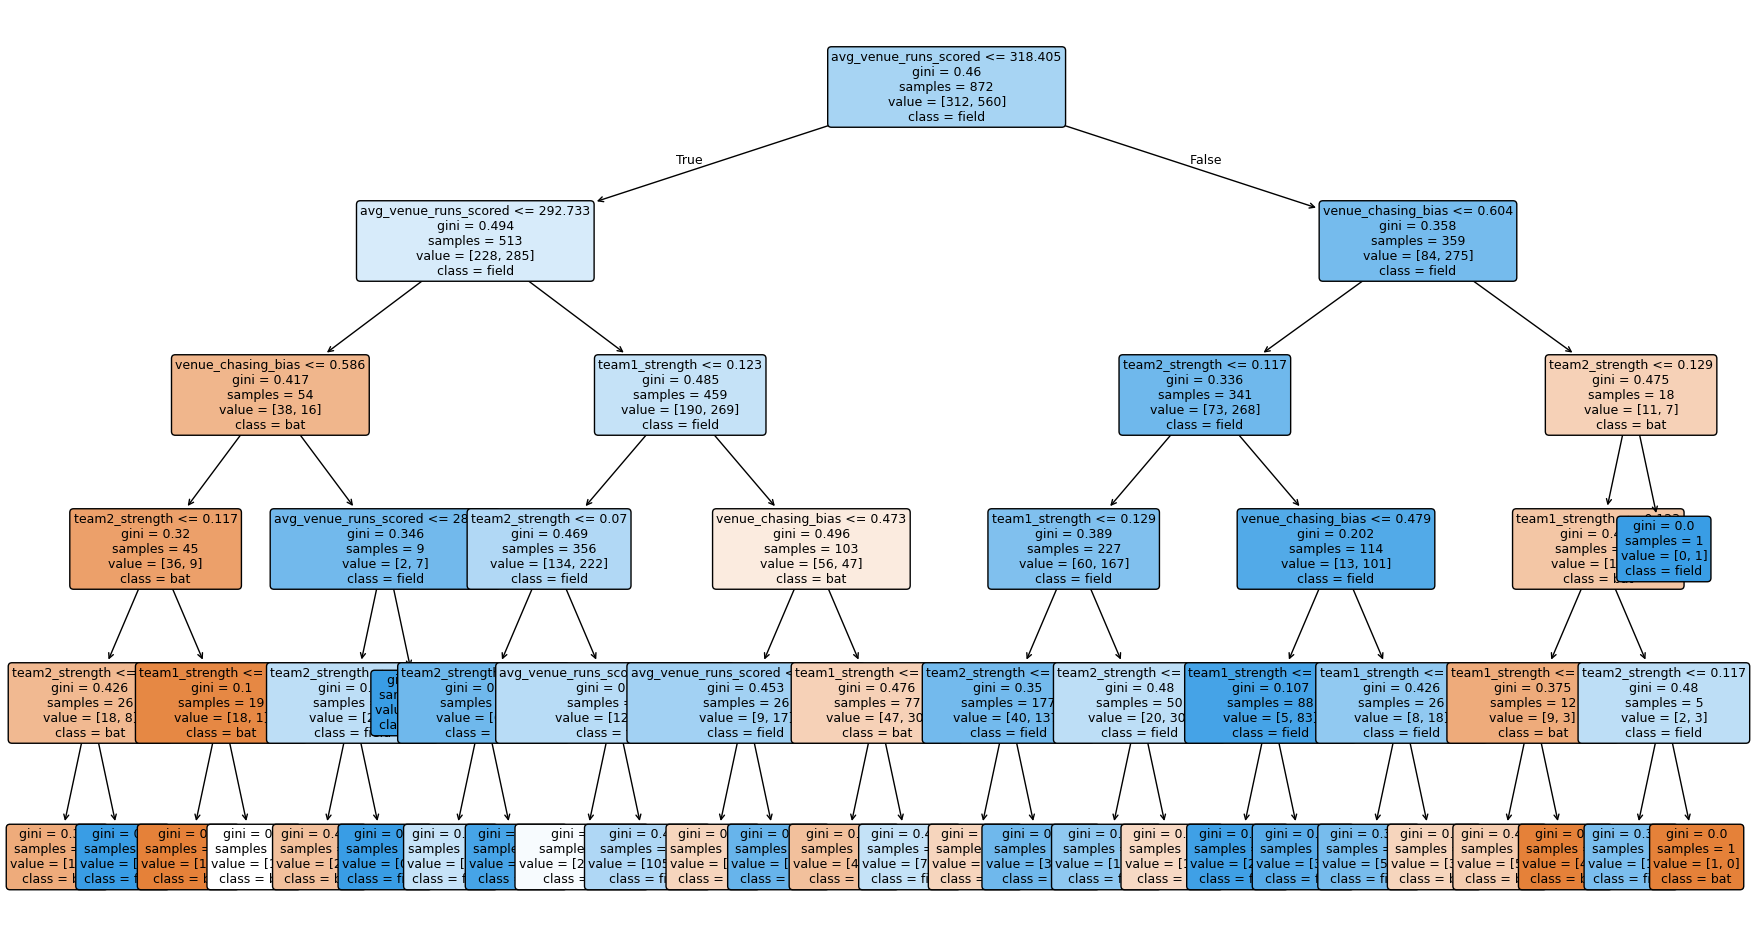

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(22, 12))
plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.show()

In [ ]:
from sklearn.tree import export_text

rules = export_text(tree_model, feature_names=list(X.columns))
print(rules)

|--- avg_venue_runs_scored <= 318.41
|   |--- avg_venue_runs_scored <= 292.73
|   |   |--- venue_chasing_bias <= 0.59
|   |   |   |--- team2_strength <= 0.12
|   |   |   |   |--- team2_strength <= 0.11
|   |   |   |   |   |--- class: bat
|   |   |   |   |--- team2_strength >  0.11
|   |   |   |   |   |--- class: field
|   |   |   |--- team2_strength >  0.12
|   |   |   |   |--- team1_strength <= 0.12
|   |   |   |   |   |--- class: bat
|   |   |   |   |--- team1_strength >  0.12
|   |   |   |   |   |--- class: bat
|   |   |--- venue_chasing_bias >  0.59
|   |   |   |--- avg_venue_runs_scored <= 281.35
|   |   |   |   |--- team2_strength <= 0.12
|   |   |   |   |   |--- class: bat
|   |   |   |   |--- team2_strength >  0.12
|   |   |   |   |   |--- class: field
|   |   |   |--- avg_venue_runs_scored >  281.35
|   |   |   |   |--- class: field
|   |--- avg_venue_runs_scored >  292.73
|   |   |--- team1_strength <= 0.12
|   |   |   |--- team2_strength <= 0.07
|   |   |   |   |--- team2_st

In [ ]:
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

avg_venue_runs_scored        0.408819
team2_strength               0.216658
venue_chasing_bias           0.208206
team1_strength               0.166318
match_importance_League      0.000000
match_importance_Play-Off    0.000000
dtype: float64
